In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [4]:
# Parameters

mu = 0.16905
sigma = 0.4907
r = 0.0011888

t = 0
T = 0.291667
Delta = 10 / 252

S0 = 152.51
K = 170
M = 100

N = 100000

In [6]:
def d1(t, S):
    tau = T - t
    
    return (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))


def d2(t, S):
    tau = T - t
    
    return d1(t, S) - sigma * np.sqrt(tau)

In [8]:
def put_price(t, S):
    tau = T - t
    
    d1_value = d1(t, S)
    d2_value = d2(t, S)
    
    return (
        S * (norm.cdf(d1_value) - 1)
        + K * np.exp(-r * tau) * (1 - norm.cdf(d2_value))
    )

In [10]:
def delta(t, S):
    return norm.cdf(d1(t, S)) - 1


def gamma(t, S):
    tau = T - t
    
    return (
        norm.pdf(d1(t, S))
        / (S * sigma * np.sqrt(tau))
    )


def theta(t, S):
    tau = T - t
    
    return (
        -sigma * S * norm.pdf(d1(t, S))
        / (2 * np.sqrt(tau))
        + K * r * np.exp(-r * tau)
        * (1 - norm.cdf(d2(t, S)))
    )

In [12]:
P0 = put_price(t, S0)

lambda_ = delta(t, S0)
gamma_0 = gamma(t, S0)
theta_0 = theta(t, S0)

print("Put price:", P0)
print("Delta:", lambda_)
print("Gamma:", gamma_0)
print("Theta:", theta_0)

Put price: 27.098959883059933
Delta: -0.6086744776753927
Gamma: 0.009502255374008145
Theta: -26.46624019362534


In [14]:
np.random.seed(42)

Z = np.random.normal(0, 1, N)

X = (
    (mu - 0.5 * sigma**2) * Delta
    + sigma * np.sqrt(Delta) * Z
)

S_next = S0 * np.exp(X)

In [16]:
P_next = put_price(t + Delta, S_next)

L_full = M * (
    P_next
    - P0
    - lambda_ * S0 * (np.exp(X) - 1)
)

In [24]:
L_lin_value = M * theta_0 * Delta

L_lin = np.full(N, L_lin_value)

In [18]:
L_quad = (
    M * theta_0 * Delta
    + 0.5 * M * gamma_0 * S0**2 * X**2
)

In [32]:
print("Full:")
print("Mean =", np.mean(L_full))
print("Std =", np.std(L_full))

print()

print("Linearized:")
print("Mean =", np.mean(L_lin))
print("Std =", np.std(L_lin))

print()

print("Second order:")
print("Mean =", np.mean(L_quad))
print("Std =", np.std(L_quad))

Full:
Mean = 1.2588491166097433
Std = 154.9089907085451

Linearized:
Mean = -105.02476267311638
Std = 4.263256414560601e-14

Second order:
Mean = 0.8014354324053324
Std = 149.35462181424694


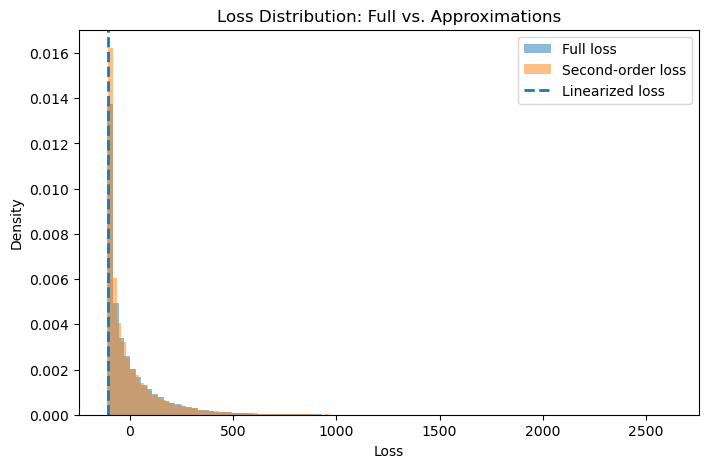

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(
    L_full,
    bins=100,
    density=True,
    alpha=0.5,
    label="Full loss"
)

plt.hist(
    L_quad,
    bins=100,
    density=True,
    alpha=0.5,
    label="Second-order loss"
)

plt.axvline(
    L_lin_value,
    linestyle="--",
    linewidth=2,
    label="Linearized loss"
)

plt.xlabel("Loss")
plt.ylabel("Density")
plt.title("Loss Distribution: Full vs. Approximations")
plt.legend()

plt.savefig(
    "loss_distribution_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()